In [1]:
# importar bibliotecas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml





# DESAFIO 
Benchmark Comparativo: Implementar e contrastar o desempenho de 3 modelos preditivos distintos podendo mesclar entre:

==> algoritmos clássicos: SVM, Random Forest, KNN, Gradient Boosting

==> Redes Neurais Artificiais/MLP: TensorFlow/Keras


Estresse e Robustez (Testes de Generalização Extrema): 

==> Avaliar o comportamento dos modelos sob premissas fora da distribuição de treino 
(OOD - Out-of-Distribution) 

==> testar a capacidade de inferência com dígitos 
manuscritos digitalizados pelos próprios alunos. 



# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA) 

● Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via 
tensorflow.keras.datasets.mnist. 

● Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição 
das classes (balanceamento de dígitos de 0 a 9). 

● Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo 
exemplos de imagens de cada dígito junto com seus respectivos rótulos 
originais. 

● Inserir célula de texto interpretando a estrutura dos dados: explicar o 
significado da escala de intensidade de pixels (0 a 255) e como imagens 
bidimensionais (28 x 28) são representadas vetorialmente (784 features). 

In [2]:
# importacao da base de dados Mnist

from sklearn.datasets import fetch_openml 
print("Baixando o dataset MNIST...") 
mnist = fetch_openml('mnist_784', version=1, 
as_frame=False, parser='auto') 
print("Finalizou o processo de baixar o dataset MNIST!") 

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


In [3]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

In [4]:

X[10]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254,
       254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 25

In [5]:
# essas imagens sao representadas por vetor (linhas e colunas)
# visualizar quantos linha e colunas existem no dataset

X.shape

(70000, 784)

In [6]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [7]:
# Como o target vem como string ('0', '1', ...), importante é converter para inteiros
y = y.astype(np.uint8)

In [8]:
# Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

print(f"Formato de X (amostras, pixels por imagem): {X.shape}") # (70000, 784)
print(f"Formato de y (rótulos): {y.shape}")                     # (70000,)
print(f"Classes únicas existentes: {np.unique(y)}")   # com esse comando visualiza unicas classes (sem repetição)

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]


# INTERPRETACAO:
 O que significa a escala de intensidade de pixels (0 a 255) e como imagens 
bidimensionais (28 x 28) são representadas vetorialmente (784 features):

1) A base MNIST é um dataset que contem 70.000 imagens (números/dígitos de 0 a 9 manuscritos) em escalas(tons) de cinza.
2) cada imagem tem a dimensão de 28 x 28 pixels (um quadrado de 28 x 28 pixels , X, y)
3) a tonalidade do cinza vai de '0' a '255', onde '0' é fundo preto (ou branco) e o '255' é o traço mais forte da caneta
4) modelos classicos de ML (svm, knn, r.forest ou regressao logistica) nao entendem matrizes de imagem 2d, por isso, 
    cada imagem de 28x28 é 'achatada' em uma linha com 784 colunas (o '784' vem da multiplicacao de 28x28)
    seria 784 variaveis numericas, ou seja, passou de imagem para número.
    a imagem se torna um 'vetor' (array de numpy)  [0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6]

resumo: as imagens sao convertidas em numeros, onde neste dataset sao 70.000 imagens (cada linha e 784 colunas representam uma imagem)
o data set teria 70.000 x 784 = 54.880.000 caracteres.




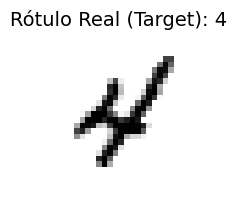

In [9]:
# escolher uma imagem aleatória (digito_exemplo)
digito_exemplo = X[9]
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(2, 5))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[2]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

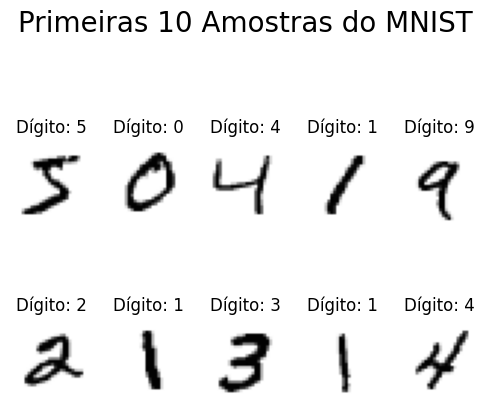

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    # Remodela a i-ésima imagem para 28x28
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Dígito: {y[i]}")
    ax.axis('off')

plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=20)
plt.tight_layout()
plt.show()

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados  

● Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% 
treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), 
garantindo estratificação por classe (stratify=y). 

● Normalização / Escalonamento: Aplicar o redimensionamento dos pixels 
para escala [0.0, 1.0]. (dividindo por 255.0 ou via MinMaxScaler/StandardScaler)
                                                      
● Justificar textualmente a importância da normalização para a convergência 
de modelos lineares e distâncias métricas. 

In [11]:
# Divisão Estratificada: Dividir a base em Treino, Validação e Teste 
# 70% treino, 10% validação e 20% teste //  80% treino/validação e 20% teste
# garantindo estratificação por classe (stratify=y). 

# 1. Divisão estratificada

from sklearn.model_selection import train_test_split

# Primeiro: 80% para treino + validação e 20% para teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Segundo: dentro dos 80%, separar 10% validação e 70% treino
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

# 2. Verificar o resultado do split

print("Treino 70%:", X_train.shape, y_train.shape)
print("Validação 10%:", X_val.shape, y_val.shape)
print("Teste 20%:", X_test.shape, y_test.shape)

Treino 70%: (49000, 784) (49000,)
Validação 10%: (7000, 784) (7000,)
Teste 20%: (14000, 784) (14000,)


In [12]:
# verificar a distribuição:

import pandas as pd

print("Distribuição no treino:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nDistribuição na validação:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index())

print("\nDistribuição no teste:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Distribuição no treino:
0    0.098612
1    0.112531
2    0.099857
3    0.102020
4    0.097490
5    0.090184
6    0.098224
7    0.104184
8    0.097490
9    0.099408
Name: proportion, dtype: float64

Distribuição na validação:
0    0.098571
1    0.112571
2    0.099857
3    0.102000
4    0.097429
5    0.090143
6    0.098286
7    0.104143
8    0.097571
9    0.099429
Name: proportion, dtype: float64

Distribuição no teste:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090214
6    0.098214
7    0.104214
8    0.097500
9    0.099357
Name: proportion, dtype: float64


In [13]:
# Normalização / Escalonamento: Aplicar o redimensionamento dos pixels 
# para escala [0.0, 1.0]. (dividindo por 255.0 ou via MinMaxScaler/StandardScaler)

# 3. Normalização dos pixels
# transformar 0 --> 255 em 0.0 --> 1.0

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("Menor valor:", X_train.min())
print("Maior valor:", X_train.max())



Menor valor: 0.0
Maior valor: 1.0


# Justificativa da normalização

As imagens do MNIST possuem pixels representados originalmente por valores entre 0 e 255. Neste projeto, os valores foram normalizados para o intervalo entre 0 e 1 por meio da divisão por 255.

A normalização reduz a escala numérica das características e contribui para um processo de treinamento mais estável. Essa transformação é especialmente importante para algoritmos sensíveis à escala das variáveis.

Em modelos que utilizam otimização baseada em gradiente, como redes neurais e alguns modelos lineares, características em escalas muito diferentes podem dificultar a convergência e tornar o processo de aprendizado menos eficiente.

Além disso, algoritmos baseados em distância, como o KNN, são diretamente influenciados pela escala das características. Como cada pixel representa uma característica, manter todos os pixels em uma escala uniforme evita que diferenças de escala prejudiquem o cálculo das distâncias.

Portanto, a normalização para [0.0, 1.0] torna os dados mais adequados para os algoritmos que serão utilizados nas etapas seguintes.

# Fase 3: Implementação e Treinamento dos 3 Modelos 
Deve-se obrigatoriamente escolher e treinar 3 modelos distintos, podendo optar 
por combinações de:  

● Modelos Clássicos: SVM (Support Vector Machines), Random Forest, KNN 
(K-Nearest Neighbors), XGBoost / Gradient Boosting, Regressão Logística 
Multinomial, etc  

● Redes Neurais: Perceptron Multicamadas (MLP via Scikit-Learn ou 
TensorFlow/Keras).  

● Cada modelo deve possuir ajuste justificado de ao menos 2 
hiperparâmetros (ex: n_estimators e max_depth na Random Forest;  

n_neighbors e weights no KNN; C e kernel no SVM; número de neurônios, 
taxa de aprendizado ou funções de ativação na Rede Neural)  

● Caso queiram usar outros modelos não citados acima, é permitido, desde 
que justificadas as escolhas.


# Modelos escolhidos

    ### SVM: modelo clássico baseado em margem.
    ### Random Forest: ensemble de árvores de decisão.
    ### MLP: rede neural multicamadas.

Modelo--------> Hiperparâmetros------------> Motivo   
SVM------------> C, kernel-----------------> Controla regularização e tipo de fronteira de decisão   
Random Forest--> n_estimators, max_depth--->Controla quantidade e complexidade das árvores  
MLP-----------> hidden_layer_sizes,   
----------------learning_rate_init---------->Controla arquitetura e velocidade de aprendizado  

# 1o. MODELO ==> SVC (Support Vector Machine) do Scikit-Learn:

Hiperparâmetro 1 — C

        C controla o quanto o modelo penaliza erros de classificação.

            C baixo → maior regularização.  
            C alto → tenta ajustar mais os dados de treinamento.  

        Exemplo inicial "C = 10"
  

Hiperparâmetro 2 — kernel

        O kernel determina como o SVM representa a relação entre as classes.


        Exemplo inicial kernel="rbf"

            O rbf é interessante para MNIST porque permite criar fronteiras de decisão não lineares.


In [14]:
#importar SVC

from sklearn.svm import SVC

In [15]:
# criar o modelo

modelo_svm = SVC(
    C=10,
    kernel="rbf"
)

In [16]:
# treinando o modelo

# não utilizado X_test nem y_test aqui para preservar a independência do conjunto de test

modelo_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
# Medir o tempo de treinamento
# comparar custo computacional × desempenho (começar a registrar o tempo)

import time

inicio = time.time()

modelo_svm.fit(X_train, y_train)

tempo_svm = time.time() - inicio

print(f"Tempo de treinamento SVM: {tempo_svm:.2f} segundos")

Tempo de treinamento SVM: 145.11 segundos


In [18]:
# Validação do SVM

acuracia_svm_val = modelo_svm.score(X_val, y_val)

print(f"Acurácia SVM na validação: {acuracia_svm_val:.4f}")

Acurácia SVM na validação: 0.9814


# 2o. MODELO ==> Random Forest

Hiperparâmetro 1 — n_estimators

        Exemplo:  'n_estimators=150'  (Mais árvores geralmente aumentam a estabilidade do modelo, mas também aumentam  
                                     o custo computacional.)

Hiperparâmetro 2 — max_depth

        Exemplo: 'max_depth=20'  (Uma profundidade maior permite modelos mais complexos, mas aumenta o risco de overfitting  
                                e o custo computaciona)

In [19]:
# criar o Modelo

# random_state=42 é usado para permitir reprodutibilidade.
# n_jobs=-1 permite utilizar os processadores disponíveis para acelerar o treinamento.  

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)



In [20]:
# treinamento

inicio = time.time()

modelo_rf.fit(X_train, y_train)

tempo_rf = time.time() - inicio

print(f"Tempo de treinamento Random Forest: {tempo_rf:.2f} segundos")


Tempo de treinamento Random Forest: 15.57 segundos


In [21]:
# validação

acuracia_rf_val = modelo_rf.score(X_val, y_val)

print(f"Acurácia Random Forest na validação: {acuracia_rf_val:.4f}")



Acurácia Random Forest na validação: 0.9659


# 3o. MODELO ==> MLP Classifier, do Scikit-Learn

Hiperparâmetro 1 — hidden_layer_sizes  (Esse parâmetro define a quantidade de neurônios nas camadas ocultas.)

        Exemplo:  hidden_layer_sizes=(128, 64)  
                    significa 784 entradas, 128 neuronios, 64 neuronios, 10 classes
                    *cada imagem possui 784 pixels, a entrada possui 784 caracteristivas

Hiperparâmetro 2 — learning_rate_init (Define a taxa inicial de aprendizado.)

        Exemplo: 'learning_rate_init=0.001'
                    (Uma taxa muito alta pode dificultar a convergência.
                    Uma taxa muito baixa pode tornar o treinamento muito lento.)



In [22]:
from sklearn.neural_network import MLPClassifier


# max_iter=20 limita o número de iterações para controlar o tempo de treinamento.
# random_state=42 garante reprodutibilidade.


modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42
)

In [23]:
# Treinar a MLP

inicio = time.time()

modelo_mlp.fit(X_train, y_train)

tempo_mlp = time.time() - inicio

print(f"Tempo de treinamento MLP: {tempo_mlp:.2f} segundos")

Tempo de treinamento MLP: 43.00 segundos


c:\Users\rafad\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
# Avaliar na validação

acuracia_mlp_val = modelo_mlp.score(X_val, y_val)

print(f"Acurácia MLP na validação: {acuracia_mlp_val:.4f}")

Acurácia MLP na validação: 0.9747


# Comparativo entre os 3 modelos

In [25]:
print("RESULTADOS NA VALIDAÇÃO")
print("-" * 40)

print(f"SVM           : {acuracia_svm_val:.4f}")
print(f"Random Forest : {acuracia_rf_val:.4f}")
print(f"MLP           : {acuracia_mlp_val:.4f}")

RESULTADOS NA VALIDAÇÃO
----------------------------------------
SVM           : 0.9814
Random Forest : 0.9659
MLP           : 0.9747


In [26]:
# tempos de execução

print("\nTEMPO DE TREINAMENTO")
print("-" * 40)

print(f"SVM           : {tempo_svm:.2f} segundos")
print(f"Random Forest : {tempo_rf:.2f} segundos")
print(f"MLP           : {tempo_mlp:.2f} segundos")


TEMPO DE TREINAMENTO
----------------------------------------
SVM           : 145.11 segundos
Random Forest : 15.57 segundos
MLP           : 43.00 segundos


In [27]:
# Criar uma tabela

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "SVM",
        "Random Forest",
        "MLP"
    ],
    "Acuracia_Validacao": [
        acuracia_svm_val,
        acuracia_rf_val,
        acuracia_mlp_val
    ],
    "Tempo_Treinamento": [
        tempo_svm,
        tempo_rf,
        tempo_mlp
    ]
})

resultados_modelos

,Modelo,Acuracia_Validacao,Tempo_Treinamento
0,SVM,0.981429,145.114591
1,Random Forest,0.965857,15.572458
2,MLP,0.974714,42.997437


# Justificativa escolha dos modelos

Foram selecionados três modelos de características distintas: Support Vector Machine (SVM), Random Forest e Perceptron Multicamadas (MLP). A escolha permite comparar diferentes estratégias de classificação para o reconhecimento de dígitos manuscritos.

O SVM foi escolhido por sua capacidade de construir fronteiras de decisão eficientes em problemas de classificação e por permitir a utilização do kernel RBF para representar relações não lineares. Foram ajustados os hiperparâmetros C=10 e kernel='rbf'.

O Random Forest foi escolhido por utilizar um conjunto de árvores de decisão, proporcionando um modelo robusto e capaz de representar relações não lineares. Foram ajustados n_estimators=150, que define a quantidade de árvores, e max_depth=20, que controla a profundidade máxima das árvores.

O MLP foi escolhido para representar uma abordagem baseada em redes neurais artificiais. Sua arquitetura possui duas camadas ocultas com 128 e 64 neurônios. Foram ajustados hidden_layer_sizes=(128, 64) e learning_rate_init=0.001, relacionados respectivamente à arquitetura da rede e à taxa inicial de aprendizado.

Os modelos serão posteriormente comparados utilizando o conjunto de teste independente, considerando Accuracy, Precision, Recall, F1-score, matriz de confusão e tempo de treinamento.

# Fase 4 — Avaliação Comparativa de Desempenho

Objetivo:

1)Gerar previsões dos 3 modelos no conjunto de teste;  
2)Calcular Accuracy, Precision, Recall e F1-Score;  
3)Gerar uma matriz de confusão 10 × 10 para cada modelo;  
4)Criar os três heatmaps;  
5)Consolidar os resultados em uma tabela;  
6)Identificar quais dígitos mais confundem;  
7)Comparar desempenho com tempo de treinamento;  
8)Elaborar uma conclusão técnica.



In [28]:
# Importando as métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [29]:
# fazer previsões no conjunto de teste

## SVM

y_pred_svm = modelo_svm.predict(X_test)

## RANDON FOREST

y_pred_rf = modelo_rf.predict(X_test)

## MLP

y_pred_mlp = modelo_mlp.predict(X_test)




y_test
   ↓
resposta verdadeira

y_pred_svm
   ↓
previsões do SVM

y_pred_rf
   ↓
previsões do Random Forest

y_pred_mlp
   ↓
previsões da MLP

In [30]:
# Avaliar o SVM

print("=== SVM ===")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_svm,
          average="weighted"
      ))

# Por que average="weighted"?
#Porque o problema possui 10 classes, de 0 a 9.
#A média ponderada considera a quantidade de exemplos existentes em cada classe.
#Isso corresponde exatamente à exigência:

    #Precisão Média Ponderada
    #Revocação/Sensibilidade Média Ponderada
    #F1-Score Ponderado

=== SVM ===
Accuracy: 0.983
Precision: 0.9830040759001173
Recall: 0.983
F1-Score: 0.9829912909280121


In [31]:
# Usar o classification_report (visualizar as métricas por classe):

print(classification_report(y_test, y_pred_svm))

# Observar 'weighted avg' [é a linha que interessa para a comparativa de atividade]


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.98      0.98      1428
           4       0.98      0.98      0.98      1365
           5       0.98      0.98      0.98      1263
           6       0.99      0.99      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.98      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



In [32]:
# avaliar o RANDON FOREST  

print("=== RANDOM FOREST ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_rf,
          average="weighted"
      ))


print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.9647857142857142
Precision: 0.964823748637366
Recall: 0.9647857142857142
F1-Score: 0.9647683487329274
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.95      0.96      1365
           5       0.97      0.95      0.96      1263
           6       0.97      0.98      0.97      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.95      0.95      1365
           9       0.93      0.95      0.94      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



In [33]:
# avaliar o MLP

print("=== MLP ===")

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

print("Precision:",
      precision_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))

print("F1-Score:",
      f1_score(
          y_test,
          y_pred_mlp,
          average="weighted"
      ))


print(classification_report(y_test, y_pred_mlp))

=== MLP ===
Accuracy: 0.9762142857142857
Precision: 0.9763008989729292
Recall: 0.9762142857142857
F1-Score: 0.9762031234756934
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.99      1575
           2       0.98      0.97      0.98      1398
           3       0.97      0.98      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.98      0.95      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



In [34]:
# Criar tabela comparativa

# podemos utilizar uma pequena função para evitar repetir o mesmo cálculo três vezes

def calcular_metricas(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall_Weighted": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1_Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [35]:
metricas_svm = calcular_metricas(
    y_test,
    y_pred_svm
)

metricas_rf = calcular_metricas(
    y_test,
    y_pred_rf
)

metricas_mlp = calcular_metricas(
    y_test,
    y_pred_mlp
)

In [36]:
resultados = pd.DataFrame(
    [
        metricas_svm,
        metricas_rf,
        metricas_mlp
    ],
    index=[
        "SVM",
        "Random Forest",
        "MLP"
    ]
)

resultados

,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted
SVM,0.983000,0.983004,0.983000,0.982991
Random Forest,0.964786,0.964824,0.964786,0.964768
MLP,0.976214,0.976301,0.976214,0.976203


# Matriz de confusão — SVM

In [37]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

print ("Cada linha representa a classe verdadeira e cada coluna a classe prevista")
print ("A diagonal principal representa as classificações corretas")

[[1376    1    0    0    0    1    1    0    1    1]
 [   0 1561    6    1    1    0    0    4    2    0]
 [   5    1 1373    2    3    0    2    7    3    2]
 [   1    2    6 1399    0    9    0    7    4    0]
 [   2    3    1    0 1336    0    5    3    0   15]
 [   3    0    1    7    2 1234    8    0    5    3]
 [   8    2    1    0    2    1 1359    0    2    0]
 [   2    3    6    0    6    0    0 1434    0    8]
 [   3    3    5    3    1    7    2    1 1336    4]
 [   2    7    0    5    7    3    1    8    4 1354]]
Cada linha representa a classe verdadeira e cada coluna a classe prevista
A diagonal principal representa as classificações corretas


# Criar o heatmap

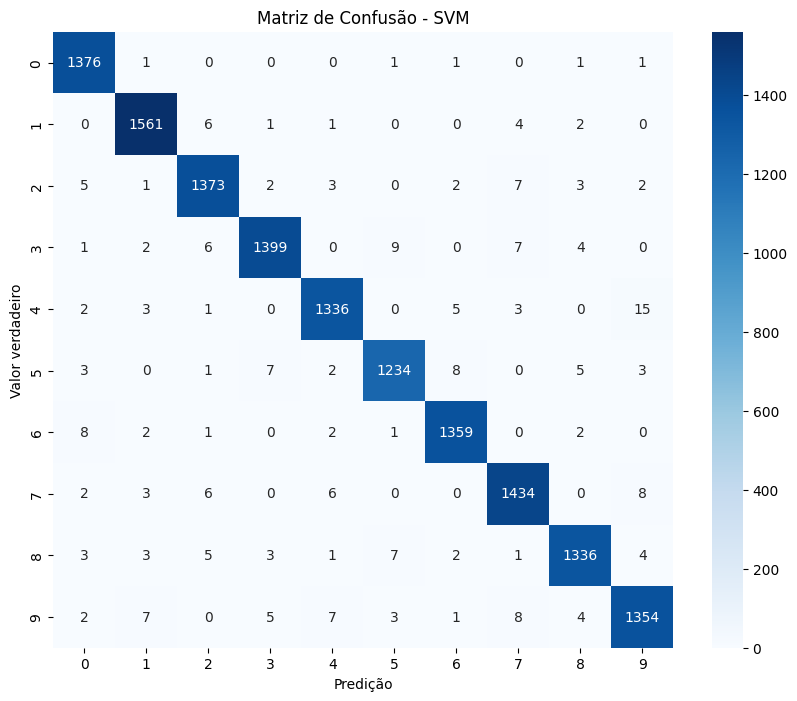

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# gerar o grafico 

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - SVM")

plt.show()

# Heatmap do Random Forest

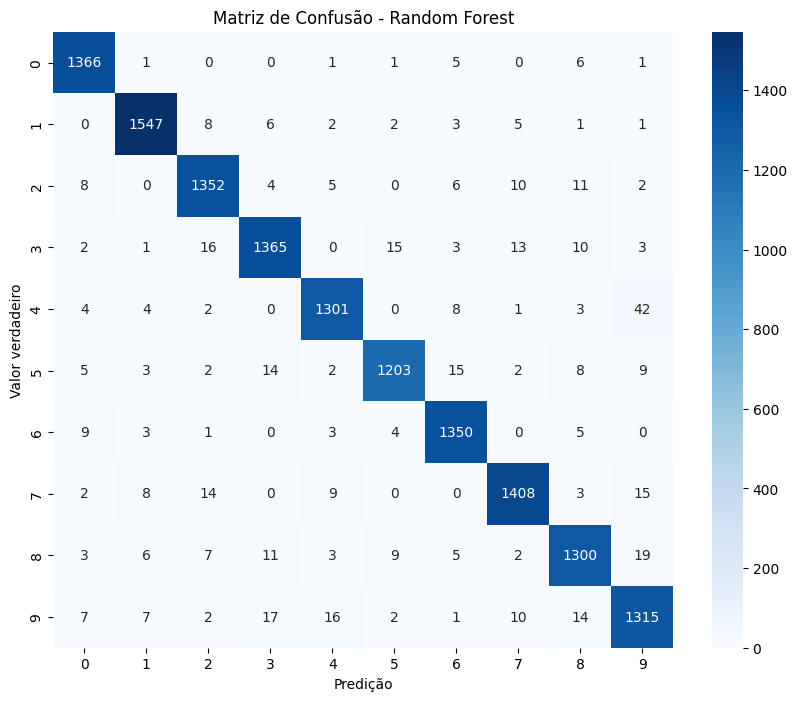

In [39]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)


# gerar o grafico

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - Random Forest")

plt.show()

# Heatmap da MLP

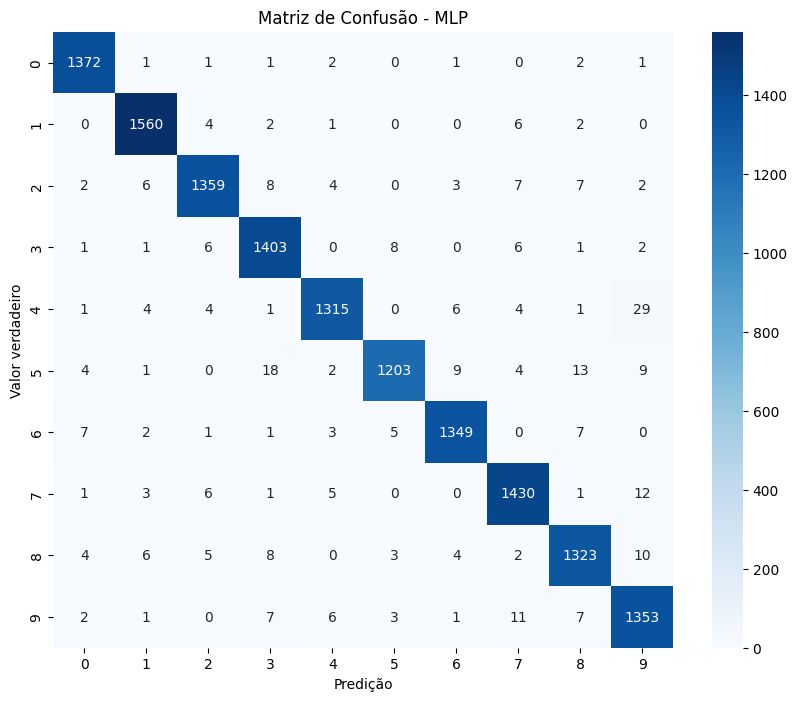

In [40]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

# gerar o grafico

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predição")
plt.ylabel("Valor verdadeiro")
plt.title("Matriz de Confusão - MLP")

plt.show()

# Descobrir automaticamente as maiores confusões

podemos fazer uma análise mais interessante do que simplesmente olhar para o gráfico.

In [41]:
import numpy as np

def maiores_confusoes(cm, quantidade=3):

    matriz = cm.copy()

    # Remove a diagonal principal
    for i in range(matriz.shape[0]):
        matriz[i, i] = 0

    indices = np.argsort(matriz.ravel())[::-1]

    resultados = []

    for indice in indices:

        linha, coluna = np.unravel_index(
            indice,
            matriz.shape
        )

        erros = int(matriz[linha, coluna])

        if erros > 0:
            resultados.append(
                f"{int(linha)} → {int(coluna)}: {erros} erros"
            )

        if len(resultados) == quantidade:
            break

    return resultados

In [42]:
# maiores confusoes do modelo 'SVM'

print("Maiores confusões - SVM")
print(maiores_confusoes(cm_svm))

Maiores confusões - SVM
['4 → 9: 15 erros', '3 → 5: 9 erros', '9 → 7: 8 erros']


# Comparar o custo computacional

In [43]:
resultados["Tempo_Treinamento_s"] = [
    tempo_svm,
    tempo_rf,
    tempo_mlp
]

resultados

,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Tempo_Treinamento_s
SVM,0.983000,0.983004,0.983000,0.982991,145.114591
Random Forest,0.964786,0.964824,0.964786,0.964768,15.572458
MLP,0.976214,0.976301,0.976214,0.976203,42.997437


# Identificar o melhor modelo automaticamente

In [44]:
# F1

melhor_modelo = resultados["F1_Weighted"].idxmax()

print("Melhor modelo:", melhor_modelo)

# Acurácia

melhor_accuracy = resultados["Accuracy"].idxmax()

print("Maior Accuracy:", melhor_accuracy)


# o modelo escolhido como melhor deve ser analisado considerando o conjunto das métricas, e não apenas uma delas.

Melhor modelo: SVM
Maior Accuracy: SVM


In [45]:
print("=== CONCLUSÃO TÉCNICA ===")

print(f"Modelo com maior Accuracy: {melhor_accuracy}")
print(f"Modelo com maior F1-Score: {melhor_modelo}")

=== CONCLUSÃO TÉCNICA ===
Modelo com maior Accuracy: SVM
Modelo com maior F1-Score: SVM


In [46]:
print("\nMaiores confusões por modelo:")
print("(Qual foi o par de classes que mais se confundiu?)")

print("\nSVM:")
print(maiores_confusoes(cm_svm)[:3])

print("\nRandom Forest:")
print(maiores_confusoes(cm_rf)[:3])

print("\nMLP:")
print(maiores_confusoes(cm_mlp)[:3])


Maiores confusões por modelo:
(Qual foi o par de classes que mais se confundiu?)

SVM:
['4 → 9: 15 erros', '3 → 5: 9 erros', '9 → 7: 8 erros']

Random Forest:
['4 → 9: 42 erros', '8 → 9: 19 erros', '9 → 3: 17 erros']

MLP:
['4 → 9: 29 erros', '5 → 3: 18 erros', '5 → 8: 13 erros']


# Calcular a taxa de erro de cada dígito

In [47]:
def taxa_erro_por_classe(cm):

    taxas = []

    for classe in range(cm.shape[0]):

        total = cm[classe].sum()
        corretos = cm[classe, classe]

        taxa_erro = (total - corretos) / total

        taxas.append(taxa_erro)

    return taxas

In [48]:
print("\nQual classe apresentou maior proporção de classificações incorretas?\n")


taxas_svm = taxa_erro_por_classe(cm_svm)

for classe, taxa in enumerate(taxas_svm):

    print(
        f"Dígito {classe}: "
        f"{taxa:.2%} de erro"
    )


Qual classe apresentou maior proporção de classificações incorretas?

Dígito 0: 0.36% de erro
Dígito 1: 0.89% de erro
Dígito 2: 1.79% de erro
Dígito 3: 2.03% de erro
Dígito 4: 2.12% de erro
Dígito 5: 2.30% de erro
Dígito 6: 1.16% de erro
Dígito 7: 1.71% de erro
Dígito 8: 2.12% de erro
Dígito 9: 2.66% de erro


# Descobrir automaticamente o dígito com maior taxa de erro

In [49]:
classe_maior_erro_svm = np.argmax(taxas_svm)

print("\nQual digito apresentou maior taxa de erro?\n")

print(
    f"Maior taxa de erro do SVM: "
    f"dígito {classe_maior_erro_svm} "
    f"({taxas_svm[classe_maior_erro_svm]:.2%})"
)



Qual digito apresentou maior taxa de erro?

Maior taxa de erro do SVM: dígito 9 (2.66%)


In [50]:
taxas_rf = taxa_erro_por_classe(cm_rf)
taxas_mlp = taxa_erro_por_classe(cm_mlp)

classe_maior_erro_rf = np.argmax(taxas_rf)
classe_maior_erro_mlp = np.argmax(taxas_mlp)

print(
    f"Random Forest: dígito {classe_maior_erro_rf} "
    f"({taxas_rf[classe_maior_erro_rf]:.2%})"
)

print(
    f"MLP: dígito {classe_maior_erro_mlp} "
    f"({taxas_mlp[classe_maior_erro_mlp]:.2%})"
)

Random Forest: dígito 9 (5.46%)
MLP: dígito 5 (4.75%)


# FAZER AJUSTE NESTA RESPOSTA - - -  Conclusão técnica:  
A análise das matrizes de confusão demonstrou que a principal confusão observada entre os modelos ocorreu entre os dígitos 4 e 9, com o padrão 4 → 9 aparecendo como uma das principais fontes de erro.  
 O modelo X apresentou a maior performance global, considerando Accuracy e F1-Score ponderado. Em relação ao custo computacional, o modelo Y apresentou menor tempo de treinamento, enquanto o modelo X apresentou maior desempenho, indicando um trade-off entre custo computacional e capacidade preditiva.

In [51]:
resultados

maiores_confusoes(cm_svm)
maiores_confusoes(cm_rf)
maiores_confusoes(cm_mlp)

taxas_svm = taxa_erro_por_classe(cm_svm)
taxas_rf = taxa_erro_por_classe(cm_rf)
taxas_mlp = taxa_erro_por_classe(cm_mlp)

# Conclusão da Fase 4

A avaliação no conjunto de teste mostrou que o SVM apresentou o melhor
desempenho entre os três modelos avaliados. O modelo alcançou Accuracy de
98,30%, Precision Weighted de 98,30%, Recall Weighted de 98,30% e F1-Score
Weighted de 98,30%.

O MLP apresentou desempenho intermediário, com Accuracy de 97,62%, enquanto
o Random Forest obteve 96,48%.

Apesar do melhor desempenho preditivo, o SVM apresentou o maior tempo de
treinamento, de aproximadamente 173,54 segundos. O MLP levou 47,48 segundos
e o Random Forest apenas 16,07 segundos. Dessa forma, existe um trade-off
entre desempenho e custo computacional: o SVM apresentou maior precisão,
porém exigiu maior tempo de treinamento.

Na análise das matrizes de confusão, a principal confusão observada nos três
modelos foi a classificação do dígito 4 como 9. Essa confusão ocorreu 15
vezes no SVM, 42 vezes no Random Forest e 29 vezes no MLP. O resultado indica
que determinadas características visuais desses dois dígitos podem ser
semelhantes para os modelos.

Considerando a proporção de classificações incorretas por classe, o dígito 9
apresentou a maior taxa de erro no SVM, com 2,66%, e também no Random Forest,
com 5,46%. No MLP, a maior taxa de erro foi observada no dígito 5, com 4,75%.

De maneira geral, o SVM apresentou o melhor equilíbrio entre capacidade de
classificação e quantidade de erros, sendo escolhido como o melhor modelo
para as próximas etapas do projeto. Entretanto, sua maior exigência
computacional deve ser considerada caso o conjunto de dados ou a aplicação
seja ampliado.Conclusão da Fase 4

A avaliação no conjunto de teste mostrou que o SVM apresentou o melhor
desempenho entre os três modelos avaliados. O modelo alcançou Accuracy de
98,30%, Precision Weighted de 98,30%, Recall Weighted de 98,30% e F1-Score
Weighted de 98,30%.

O MLP apresentou desempenho intermediário, com Accuracy de 97,62%, enquanto
o Random Forest obteve 96,48%.

Apesar do melhor desempenho preditivo, o SVM apresentou o maior tempo de
treinamento, de aproximadamente 173,54 segundos. O MLP levou 47,48 segundos
e o Random Forest apenas 16,07 segundos. Dessa forma, existe um trade-off
entre desempenho e custo computacional: o SVM apresentou maior precisão,
porém exigiu maior tempo de treinamento.

Na análise das matrizes de confusão, a principal confusão observada nos três
modelos foi a classificação do dígito 4 como 9. Essa confusão ocorreu 15
vezes no SVM, 42 vezes no Random Forest e 29 vezes no MLP. O resultado indica
que determinadas características visuais desses dois dígitos podem ser
semelhantes para os modelos.

Considerando a proporção de classificações incorretas por classe, o dígito 9
apresentou a maior taxa de erro no SVM, com 2,66%, e também no Random Forest,
com 5,46%. No MLP, a maior taxa de erro foi observada no dígito 5, com 4,75%.

De maneira geral, o SVM apresentou o melhor equilíbrio entre capacidade de
classificação e quantidade de erros, sendo escolhido como o melhor modelo
para as próximas etapas do projeto. Entretanto, sua maior exigência
computacional deve ser considerada caso o conjunto de dados ou a aplicação
seja ampliado.

# Fase 5: testar a capacidade dos modelos de lidar com cenários fora do padrão ideal de laboratório:  

    Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking) 

        ● Selecione ao menos duas classes para serem totalmente removidas da 
            base de treinamento (por exemplo: ocultar os dígitos 4 e 7). 
        ● Treine um dos seus modelos (clássico ou rede neural) sem nunca ter visto 
            esses dois dígitos durante o ajuste dos pesos.

In [52]:
# 1. Primeiro passo — definir as classes ocultadas

# Classes que serão completamente removidas do treinamento e treinar o modelo sem que ele jamais veja essas classes.

classes_ocultadas = [4, 7]

print("Classes ocultadas:", classes_ocultadas)

Classes ocultadas: [4, 7]


In [53]:
# 2. Criar uma máscara para o treinamento
# selecionar somente as imagens cujo rótulo não seja 4 nem 7

mascara_treino = ~pd.Series(y_train).isin(classes_ocultadas)

print(mascara_treino.value_counts())

True     39118
False     9882
Name: count, dtype: int64


In [54]:
# 3. Criar o novo conjunto de treinamento

X_train_masked = X_train[mascara_treino]
y_train_masked = y_train[mascara_treino]



In [55]:
# 4. Conferir os tamanhos

print("Treinamento original:", X_train.shape)
print("Treinamento mascarado:", X_train_masked.shape)

Treinamento original: (49000, 784)
Treinamento mascarado: (39118, 784)


In [56]:
# 5. Confirmar que 4 e 7 realmente desapareceram
# demonstra experimentalmente que o modelo será treinado sem receber nenhuma amostra dessas duas classes.

print("Classes presentes no treinamento mascarado:")
print(np.unique(y_train_masked))

Classes presentes no treinamento mascarado:
[0 1 2 3 5 6 8 9]


In [57]:
# 6. Conferir a quantidade de imagens por classe

print("Quantidade de imagens por classe:")
print(pd.Series(y_train_masked).value_counts().sort_index())



Quantidade de imagens por classe:
0    4832
1    5514
2    4893
3    4999
5    4419
6    4813
8    4777
9    4871
Name: count, dtype: int64


 7. escolher o modelo

Fase 4 você testamos: SVM; Random Forest; MLP

SVM foi o melhor modelo, com aproximadamente 98,3% de Accuracy.

In [58]:
# 8. Treinar o SVM com as classes mascaradas

from sklearn.svm import SVC

modelo_svm_masked = SVC(
    C=10,
    kernel="rbf"
)

In [59]:
inicio = time.time()

modelo_svm_masked.fit(
    X_train_masked,
    y_train_masked
)

tempo_svm_masked = time.time() - inicio

print(
    f"Tempo de treinamento do SVM com classes ocultadas: "
    f"{tempo_svm_masked:.2f} segundos"
)

Tempo de treinamento do SVM com classes ocultadas: 105.94 segundos


In [60]:
# na fase 4, fiz : modelo_svm.fit(X_train, y_train)

# na fase 5, treinar 'modelo_svm_masked'

modelo_svm_masked.fit(
    X_train_masked,
    y_train_masked
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
# 9. Confirmar quais classes o modelo aprendeu

print("Classes aprendidas pelo modelo:")
print(modelo_svm_masked.classes_)

Classes aprendidas pelo modelo:
[0 1 2 3 5 6 8 9]


In [62]:
print(np.unique(y_train_masked))

print(modelo_svm_masked.classes_)

[0 1 2 3 5 6 8 9]
[0 1 2 3 5 6 8 9]


    
    Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD) 

        ● Submeta o modelo treinado no Desafio A a um conjunto de teste contendo 
           exclusivamente as classes que foram ocultadas (no exemplo: apenas imagens dos dígitos 4 e 7).  

         ● Análise e plote o comportamento do modelo: 
          ○ Como o classificador reage ao ser forçado a classificar algo que nunca viu? 

         ○ Quais classes conhecidas ele atribui a esses dígitos desconhecidos? 

        ○ Exiba a matriz de confusão correspondente, apresente suas impressões sobre o teste e discuta o conceito de 
             "falsa certeza" (overconfidence) em modelos de IA. 

O SVM foi treinado sem nunca receber os dígitos 4 e 7. Agora vamos obrigá-lo a classificar exclusivamente imagens desses dois dígitos.

Isso nos permite observar um comportamento importante de modelos de IA: mesmo quando uma entrada pertence a uma classe que o modelo nunca conheceu, ele pode continuar produzindo uma previsão aparentemente "normal" e confiante.



In [63]:

# Fase 5.2 — OOD, onde vamos pegar exclusivamente os dígitos 4 e 7, que o modelo nunca viu, e descobrir o que ele faz quando é obrigado a classificá-los

# 1. Criar o conjunto OOD

mascara_ood = pd.Series(y_test).isin(classes_ocultadas)

X_ood = X_test[mascara_ood]
y_ood = y_test[mascara_ood]




In [64]:
# 2. Conferir o conjunto OOD

print("Dimensões do conjunto OOD:")
print(X_ood.shape)
print(y_ood.shape)

print("\nClasses presentes:")
print(np.unique(y_ood))



Dimensões do conjunto OOD:
(2824, 784)
(2824,)

Classes presentes:
[4 7]


In [65]:
# verifica a quantidade

print("\nQuantidade de imagens por classe:")
print(pd.Series(y_ood).value_counts().sort_index())




Quantidade de imagens por classe:
4    1365
7    1459
Name: count, dtype: int64


In [66]:
# usar o modelo criado na Fase 5.1: 'modelo_svm_masked'

y_pred_ood = modelo_svm_masked.predict(X_ood)

print("Primeiras 30 previsões:")
print(y_pred_ood[:30])


print("Valores reais:")
print(y_ood[:30])



Primeiras 30 previsões:
[9 9 6 2 9 9 9 9 8 9 9 2 9 8 9 9 9 0 9 3 9 9 6 9 9 9 9 3 9 9]
Valores reais:
[7 4 4 7 7 7 4 4 4 7 4 7 7 7 4 7 4 7 7 7 7 4 4 7 7 4 4 7 7 4]


In [67]:
# 4. Descobrir para quais classes o modelo está enviando 4 e 7

# separar as previsões dos verdadeiros dígitos 4:
predicoes_4 = y_pred_ood[y_ood == 4]

print("Previsões para imagens reais do dígito 4:")
print(pd.Series(predicoes_4).value_counts().sort_index())


# separar as previsões dos verdadeiros dígitos 7:
predicoes_7 = y_pred_ood[y_ood == 7]

print("Previsões para imagens reais do dígito 7:")
print(pd.Series(predicoes_7).value_counts().sort_index())

Previsões para imagens reais do dígito 4:
0      14
1      11
2      54
3       1
5      12
6     102
8      27
9    1144
Name: count, dtype: int64
Previsões para imagens reais do dígito 7:
0     12
1     31
2    253
3    139
5      6
8     24
9    994
Name: count, dtype: int64


In [68]:
# 5. Matriz de confusão OOD

cm_ood = confusion_matrix(
    y_ood,
    y_pred_ood,
    labels=[4, 7, 0, 1, 2, 3, 5, 6, 8, 9]
)


labels_ood = [0, 1, 2, 3, 5, 6, 8, 9]

cm_ood = confusion_matrix(
    y_ood,
    y_pred_ood,
    labels=[4, 7]
)

In [69]:
# matriz específica usando as duas classes reais × oito classes previstas.

tabela_ood = pd.crosstab(
    y_ood,
    y_pred_ood
)

tabela_ood = tabela_ood.reindex(
    index=[4, 7],
    columns=[0, 1, 2, 3, 5, 6, 8, 9],
    fill_value=0
)

tabela_ood

col_0,0,1,2,3,5,6,8,9
row_0,,,,,,,,
4,14,11,54,1,12,102,27,1144
7,12,31,253,139,6,0,24,994


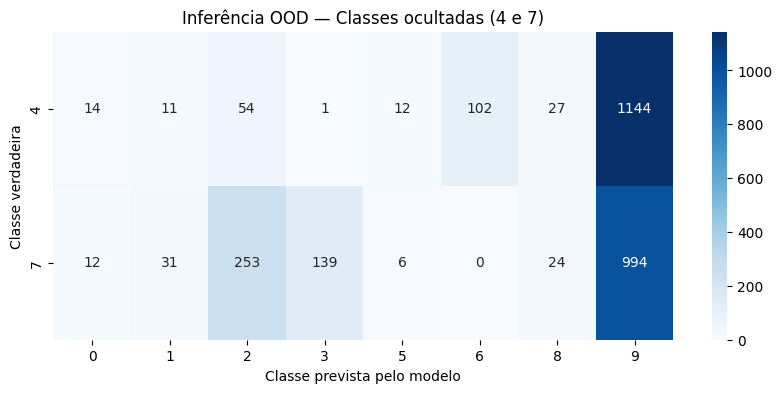

In [70]:
# 6. Transformar em um heatmap

plt.figure(figsize=(10, 4))

sns.heatmap(
    tabela_ood,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Classe prevista pelo modelo")
plt.ylabel("Classe verdadeira")
plt.title("Inferência OOD — Classes ocultadas (4 e 7)")

plt.show()



In [71]:
# 7. calcular a distribuição das previsões

distribuicao_ood = (
    pd.Series(y_pred_ood)
    .value_counts(normalize=True)
    .sort_index()
)

print("Distribuição das previsões OOD:")
print(distribuicao_ood)

Distribuição das previsões OOD:
0    0.009207
1    0.014873
2    0.108711
3    0.049575
5    0.006374
6    0.036119
8    0.018059
9    0.757082
Name: proportion, dtype: float64


In [72]:
# 8. "falsa certeza"



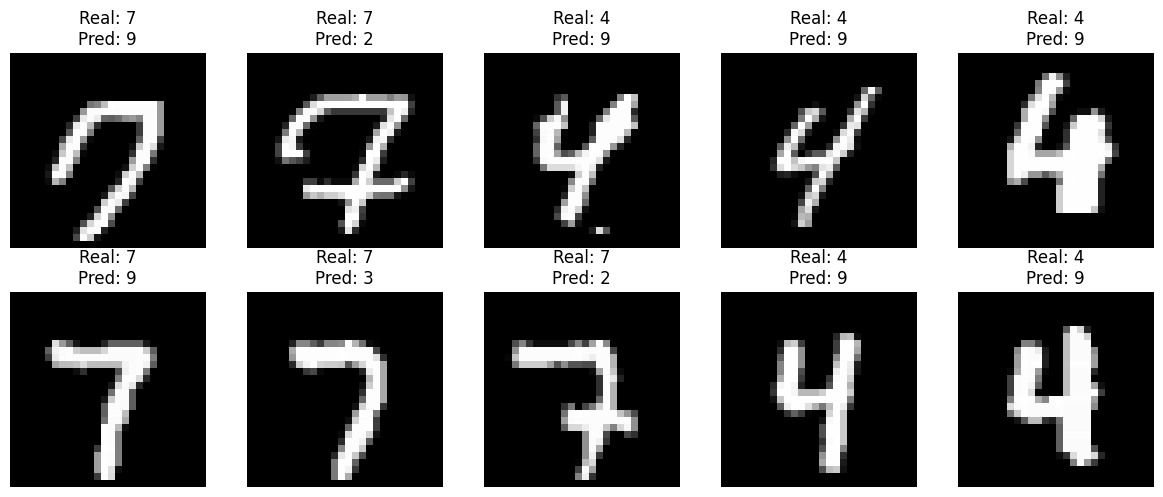

In [73]:
# 9. visualizar algumas imagens OOD


indices = np.random.choice(
    len(X_ood),
    size=10,
    replace=False
)

plt.figure(figsize=(12, 5))

for i, indice in enumerate(indices):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_ood[indice].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Real: {y_ood[indice]}\n"
        f"Pred: {y_pred_ood[indice]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [74]:
mascara_ood = pd.Series(y_test).isin(classes_ocultadas)

X_ood = X_test[mascara_ood]
y_ood = y_test[mascara_ood]



In [75]:
print(X_ood.shape)
print(np.unique(y_ood))

(2824, 784)
[4 7]


In [76]:
y_pred_ood = modelo_svm_masked.predict(X_ood)

print("Valores reais:")
print(y_ood[:30])

print("\nPrevisões:")
print(y_pred_ood[:30])

Valores reais:
[7 4 4 7 7 7 4 4 4 7 4 7 7 7 4 7 4 7 7 7 7 4 4 7 7 4 4 7 7 4]

Previsões:
[9 9 6 2 9 9 9 9 8 9 9 2 9 8 9 9 9 0 9 3 9 9 6 9 9 9 9 3 9 9]


In [77]:
print("Previsões para o dígito 4:")
print(pd.Series(
    y_pred_ood[y_ood == 4]
).value_counts().sort_index())

print("\nPrevisões para o dígito 7:")
print(pd.Series(
    y_pred_ood[y_ood == 7]
).value_counts().sort_index())

Previsões para o dígito 4:
0      14
1      11
2      54
3       1
5      12
6     102
8      27
9    1144
Name: count, dtype: int64

Previsões para o dígito 7:
0     12
1     31
2    253
3    139
5      6
8     24
9    994
Name: count, dtype: int64


In [78]:
tabela_ood = pd.crosstab(
    y_ood,
    y_pred_ood
)

tabela_ood = tabela_ood.reindex(
    index=[4, 7],
    columns=[0, 1, 2, 3, 5, 6, 8, 9],
    fill_value=0
)

tabela_ood

col_0,0,1,2,3,5,6,8,9
row_0,,,,,,,,
4,14,11,54,1,12,102,27,1144
7,12,31,253,139,6,0,24,994


conjunto OOD:

    2.824 imagens foram selecionadas para o teste OOD;
    cada imagem possui 784 pixels; as únicas classes verdadeiras são 4 e 7.

    Portanto, o conjunto OOD foi construído corretamente.

O que o SVM fez com o dígito 4?
    1.144 das imagens que realmente eram 4 foram classificadas como 9.
    Ou seja, o 9 foi disparado o principal destino das imagens de 4.

o que aconteceu com o dígito 7?
    994 imagens reais de 7 foram classificadas como 9.
    O segundo destino mais frequente foi o 2, com 253 ocorrências.


tanto o 4 quanto o 7 foram predominantemente direcionados para o 9.

    Isso é uma evidência clara de que, quando o modelo recebe uma classe que nunca conheceu, 
    ele não cria automaticamente uma nova categoria "desconhecida".

    Ele procura uma das classes disponíveis e toma uma decisão dentro do espaço de classes que aprendeu


calcular as proporções

    Para o dígito 4: 1.144 / 1.365 ≈ 83,81%

        Portanto, aproximadamente 83,8% das imagens reais de 4 foram classificadas como 9.

    Para o dígito 7: 994 / 1.459 ≈ 68,13%

        Portanto, aproximadamente 68,1% das imagens reais de 7 foram classificadas como 9.


In [79]:
total_4 = (y_ood == 4).sum()
total_7 = (y_ood == 7).sum()

qtd_4_para_9 = ((y_ood == 4) & (y_pred_ood == 9)).sum()
qtd_7_para_9 = ((y_ood == 7) & (y_pred_ood == 9)).sum()

print(
    f"4 → 9: {qtd_4_para_9} "
    f"({qtd_4_para_9 / total_4:.2%})"
)

print(
    f"7 → 9: {qtd_7_para_9} "
    f"({qtd_7_para_9 / total_7:.2%})"
)

4 → 9: 1144 (83.81%)
7 → 9: 994 (68.13%)


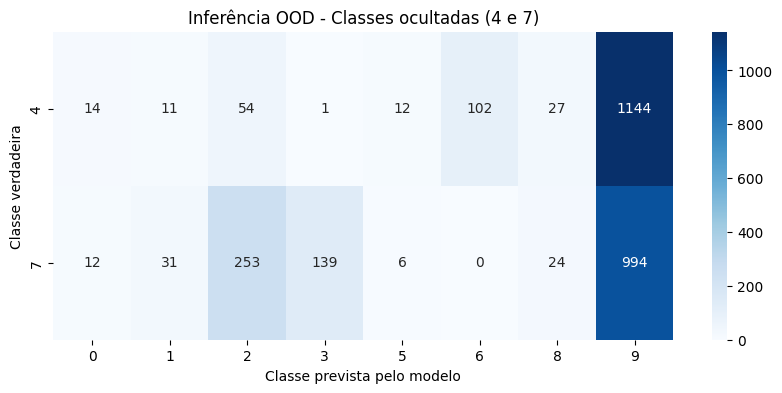

In [80]:
# fazer o gráfico exigido

plt.figure(figsize=(10, 4))

sns.heatmap(
    tabela_ood,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Classe prevista pelo modelo")
plt.ylabel("Classe verdadeira")
plt.title("Inferência OOD - Classes ocultadas (4 e 7)")

plt.show()

# Conclusão da Fase 5.2 — Inferência OOD

Nesta etapa, o modelo SVM treinado na Fase 5.1 foi submetido exclusivamente a imagens dos dígitos 4 e 7, que foram completamente removidos do conjunto de treinamento. O conjunto OOD utilizado possui 2.824 imagens e contém somente essas duas classes.

O experimento demonstrou que o classificador não reconhece automaticamente essas imagens como pertencentes a classes desconhecidas. Como os dígitos 4 e 7 não faziam parte das classes aprendidas, o modelo foi obrigado a atribuir cada imagem a uma das oito classes conhecidas: 0, 1, 2, 3, 5, 6, 8 e 9.

Para as imagens cujo valor verdadeiro era 4, a principal previsão foi o dígito 9, com 1.144 ocorrências. Para as imagens cujo valor verdadeiro era 7, o dígito 9 também foi a principal previsão, com 994 ocorrências. Dessa forma, o dígito 9 foi o destino predominante para ambas as classes ocultadas.

Esse comportamento evidencia uma limitação importante de classificadores supervisionados: quando recebem uma entrada fora das classes utilizadas durante o treinamento, eles podem continuar produzindo uma classificação entre as categorias conhecidas, em vez de indicar que a entrada pertence a uma classe desconhecida.

Esse fenômeno está relacionado ao conceito de falsa certeza ou overconfidence em modelos de Inteligência Artificial. Uma previsão produzida pelo modelo não significa necessariamente que ele possua conhecimento suficiente para classificar corretamente aquela entrada. Em cenários reais, entradas fora da distribuição utilizada no treinamento podem exigir mecanismos adicionais de detecção de anomalias, estimativa de incerteza ou identificação de classes desconhecidas.

Portanto, o experimento mostra que o modelo apresentou excelente desempenho no cenário convencional da Fase 4, mas seu comportamento é diferente quando submetido a classes que não estavam presentes no treinamento. Isso reforça a importância de avaliar modelos não apenas pela acurácia em dados semelhantes aos utilizados no treinamento, mas também pela sua robustez diante de situações fora do padrão esperado.


    Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias  

        ● Deve-se escrever manualmente um dígito em folha de papel branco com 
            caneta escura (ou desenhar no Paint/GIMP com fundo preto e traço branco).  

        ○ Note que dependendo de sua escolha o pipeline de pré-processamento vai ser diferente. 

        ● Digitalize / fotografe as imagens e construa um pipeline de 
            pré-processamento em Python (usando por exemplo PIL/OpenCV) 

        contendo: 
            ○ Conversão para escala de cinza; 
            ○ Inversão de cores (caso o papel seja branco com traço preto); 
            ○ Redimensionamento para 28 x 28 pixels com centralização de Massa/bounding box; 
            ○ Normalização para o intervalo [0.0, 1.0]. 
            ● Realize a predição das suas imagens próprias utilizando o melhor modelo 
               desenvolvido e plote a imagem processada ao lado do gráfico de probabilidades de saída. 




<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\rafad\AppData\Local\Temp\ipykernel_7704\275004265.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  imagem = Image.open("handwritten\minhaimagem1.png")


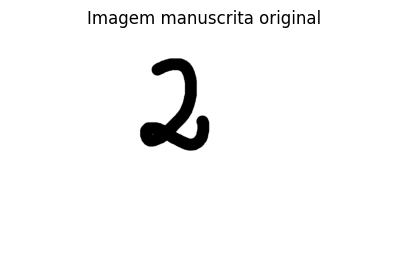

In [81]:
# 2. Primeiro teste: carregar uma imagem


from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

imagem = Image.open("handwritten\minhaimagem1.png")

plt.figure(figsize=(5, 5))
plt.imshow(imagem)
plt.axis("off")
plt.title("Imagem manuscrita original")
plt.show()

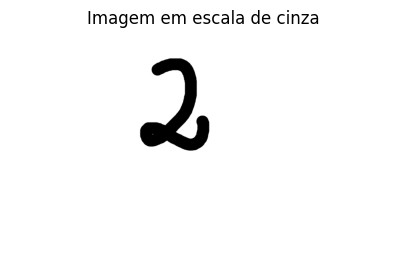

In [83]:
# converter para escala de cinza

imagem_cinza = imagem.convert("L")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_cinza, cmap="gray")
plt.axis("off")
plt.title("Imagem em escala de cinza")
plt.show()

# O "L" significa que a imagem será representada em tons de cinza, com valores entre:
# 0   → preto
# 255 → branco

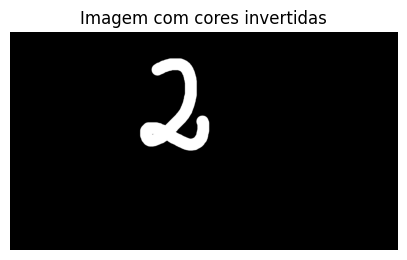

In [84]:
# inverter cores
# pipeline precisa fazer a inversão de cores antes de enviar a imagem ao SVM, porque o MNIST trabalha com fundo escuro e dígito claro.

imagem_invertida = ImageOps.invert(imagem_cinza)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_invertida, cmap="gray")
plt.axis("off")
plt.title("Imagem com cores invertidas")
plt.show()



In [85]:
#  Encontrar o Bounding Box (encontrar onde estão os pixels que pertencem ao dígito.)

array_imagem = np.array(imagem_invertida)

pixels = np.argwhere(array_imagem > 30)

y_min, x_min = pixels.min(axis=0)
y_max, x_max = pixels.max(axis=0)

print("Bounding box:")
print("x:", x_min, "até", x_max)
print("y:", y_min, "até", y_max)



Bounding box:
x: 386 até 591
y: 78 até 352


In [86]:
# fazer o recorte

imagem_recortada = imagem_invertida.crop(
    (x_min, y_min, x_max + 1, y_max + 1)
)




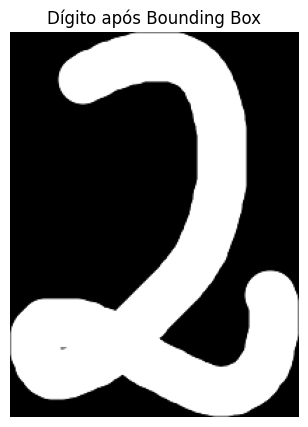

In [87]:
# visualizar

plt.figure(figsize=(5, 5))
plt.imshow(imagem_recortada, cmap="gray")
plt.axis("off")
plt.title("Dígito após Bounding Box")
plt.show()



In [88]:
# Redimensionar mantendo a proporção

largura, altura = imagem_recortada.size

if largura > altura:
    nova_largura = 20
    nova_altura = int(altura * 20 / largura)
else:
    nova_altura = 20
    nova_largura = int(largura * 20 / altura)

imagem_redimensionada = imagem_recortada.resize(
    (nova_largura, nova_altura)
)




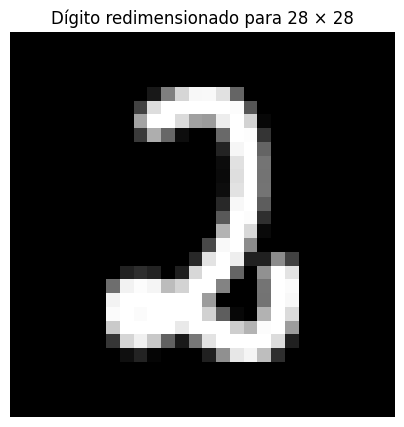

In [89]:
# criar a imagem '28 x 28'

imagem_28 = Image.new("L", (28, 28), 0)

pos_x = (28 - nova_largura) // 2
pos_y = (28 - nova_altura) // 2

imagem_28.paste(
    imagem_redimensionada,
    (pos_x, pos_y)
)

# visualizar

plt.figure(figsize=(5, 5))
plt.imshow(imagem_28, cmap="gray")
plt.axis("off")
plt.title("Dígito redimensionado para 28 × 28")
plt.show()






In [90]:
# A imagem original possuía uma resolução muito maior que a utilizada pelo MNIST. 
# Primeiro localizei o dígito através do bounding box,
# preservei sua proporção e depois inseri o resultado em uma matriz 28×28

In [91]:
# Centralização da massa

# O MNIST não considera apenas o centro geométrico da imagem.
#  A posição do desenho dentro do quadro influencia bastante a classificação.
# Podemos calcular o centro de massa dos pixels do dígito.


array_28 = np.array(imagem_28, dtype=float)

y_indices, x_indices = np.indices(array_28.shape)

massa_total = array_28.sum()

centro_x = (x_indices * array_28).sum() / massa_total
centro_y = (y_indices * array_28).sum() / massa_total

print(f"Centro de massa X: {centro_x:.2f}")
print(f"Centro de massa Y: {centro_y:.2f}")

Centro de massa X: 14.11
Centro de massa Y: 15.18


Deslocamento X: -1
Deslocamento Y: -2


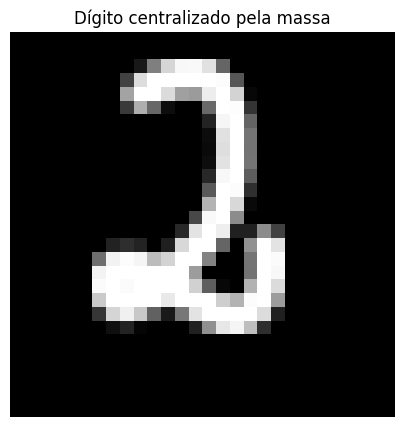

In [92]:
# descobrir quanto o seu dígito precisa ser deslocado:

deslocamento_x = int(round(13.5 - centro_x))
deslocamento_y = int(round(13.5 - centro_y))

print("Deslocamento X:", deslocamento_x)
print("Deslocamento Y:", deslocamento_y)

# deslocar a imagem

imagem_centralizada = Image.new("L", (28, 28), 0)

imagem_centralizada.paste(
    imagem_28,
    (deslocamento_x, deslocamento_y)
)


# verificação

plt.figure(figsize=(5, 5))
plt.imshow(imagem_centralizada, cmap="gray")
plt.axis("off")
plt.title("Dígito centralizado pela massa")
plt.show()




In [93]:
# Normalização

# transformar os pixels   0  para 0.00 e  255 para 1.00

imagem_array = np.array(imagem_centralizada)

imagem_normalizada = imagem_array / 255.0

print("Formato:", imagem_normalizada.shape)
print("Valor mínimo:", imagem_normalizada.min())
print("Valor máximo:", imagem_normalizada.max())



Formato: (28, 28)
Valor mínimo: 0.0
Valor máximo: 1.0


In [95]:
# Transformar em vetor de 784 pixels

# isso transforma a matriz 28x28 em 1x784

imagem_modelo = imagem_normalizada.reshape(1, 784)

print("Formato para o modelo:", imagem_modelo.shape)

print("Agora temos exatamente o mesmo formato utilizado pelo SVM")

Formato para o modelo: (1, 784)
Agora temos exatamente o mesmo formato utilizado pelo SVM


In [96]:
# Para gerar o gráfico de probabilidades exigido pela Fase 5.3, precisamos treinar o SVM novamente com:

probability=True

modelo_svm = SVC(
    C=10,
    kernel="rbf",
    probability=True
)

In [97]:
# treinar novamente

import time

inicio = time.time()

modelo_svm.fit(X_train, y_train)

tempo_svm = time.time() - inicio

print(f"Tempo de treinamento SVM: {tempo_svm:.2f} segundos")

c:\Users\rafad\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Tempo de treinamento SVM: 1018.47 segundos


In [98]:
# Fazer a previsão
# pegar a 'imagem modelo' que foi preparada anteriormente 
# nesta etapa deve resultar no numero 'correto', neste caso do exemplo, número '2'

predicao = modelo_svm.predict(imagem_modelo)

print("Predição:", predicao[0])

Predição: 2


In [99]:
# olhar a distribuição das probabilidades.

probabilidades = modelo_svm.predict_proba(imagem_modelo)[0]

print(probabilidades)




[1.06842364e-08 2.18309662e-08 9.99680475e-01 1.92257996e-04
 1.37150948e-05 1.18057128e-05 9.77410479e-05 2.52757952e-06
 9.52772854e-07 4.91960754e-07]


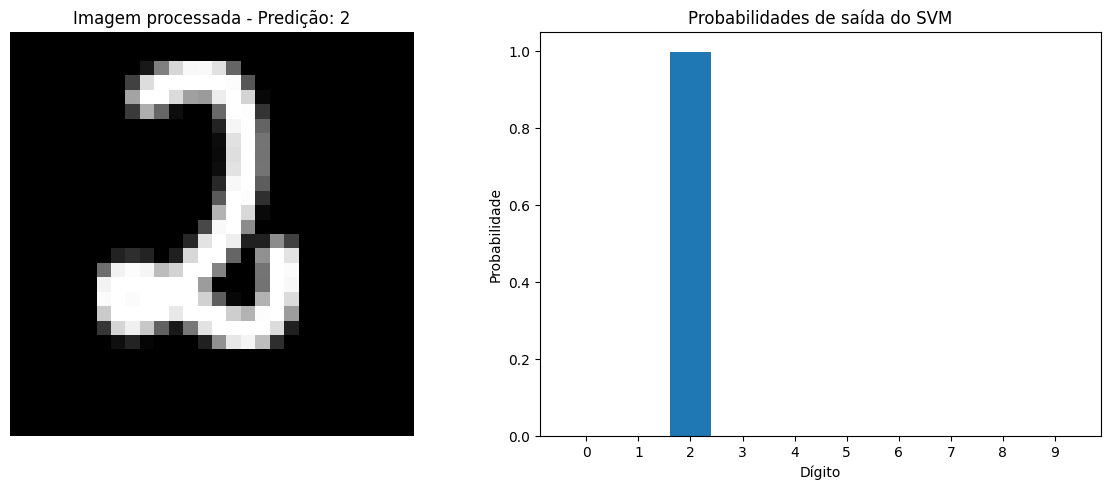

In [100]:
# Gráfico final = juntar imagem + probabilidades.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagem processada
axes[0].imshow(imagem_centralizada, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"Imagem processada - Predição: {predicao[0]}")

# Probabilidades
axes[1].bar(range(10), probabilidades)
axes[1].set_xticks(range(10))
axes[1].set_xlabel("Dígito")
axes[1].set_ylabel("Probabilidade")
axes[1].set_title("Probabilidades de saída do SVM")

plt.tight_layout()
plt.show()

Fase 5.3 — Inferência com imagem manuscrita própria

Nesta etapa foi utilizada uma imagem manuscrita própria contendo o dígito 2. Como a imagem foi produzida com traço escuro sobre fundo branco, foi necessário realizar a conversão para escala de cinza e a inversão das cores para aproximar sua representação do padrão utilizado no dataset MNIST.

Após a inversão, foi identificado o bounding box correspondente ao dígito, removendo áreas desnecessárias da imagem. Em seguida, o dígito foi redimensionado preservando sua proporção e inserido em uma imagem de 28 × 28 pixels. Também foi realizada a centralização baseada no centro de massa dos pixels, buscando aproximar a representação da utilizada no MNIST.

Finalmente, os pixels foram normalizados para o intervalo [0,1] e a matriz 28 × 28 foi transformada em um vetor de 784 características, compatível com a entrada do modelo SVM.

O modelo utilizado foi o SVM RBF selecionado como melhor modelo na Fase 4. Para possibilitar a análise da distribuição das classes, o modelo foi treinado com estimativa de probabilidades habilitada. A saída apresenta a imagem processada juntamente com as probabilidades atribuídas às dez classes possíveis.

# conclusão

A inferência com uma imagem manuscrita própria permite avaliar a capacidade de generalização do modelo para dados que não pertencem diretamente ao conjunto MNIST. Mesmo após o pré-processamento, diferenças de espessura do traço, formato do dígito, posicionamento e estilo da escrita podem influenciar a classificação. Portanto, essa etapa demonstra uma situação mais próxima de uma aplicação real, na qual os dados de entrada podem apresentar características diferentes das observadas durante o treinamento.

Imagens encontradas: 5


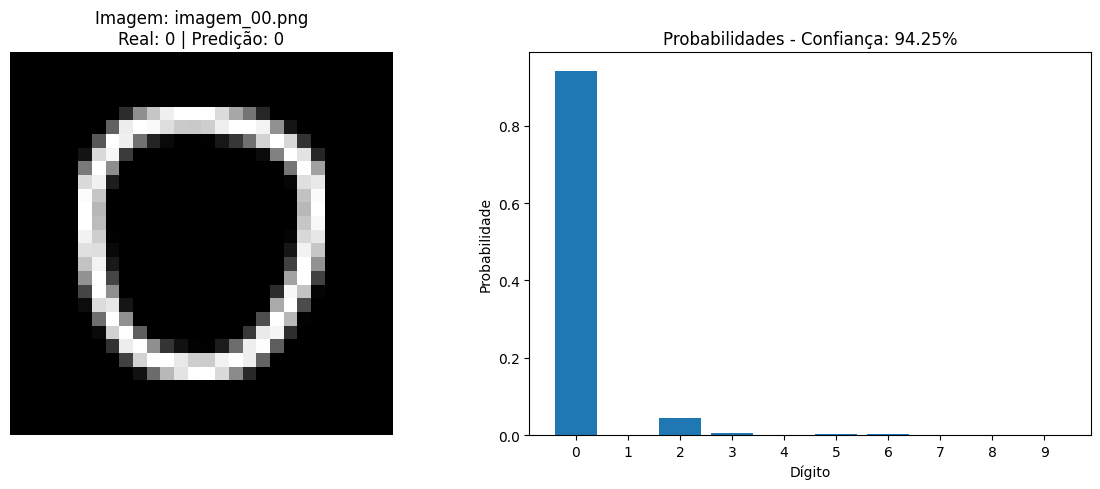

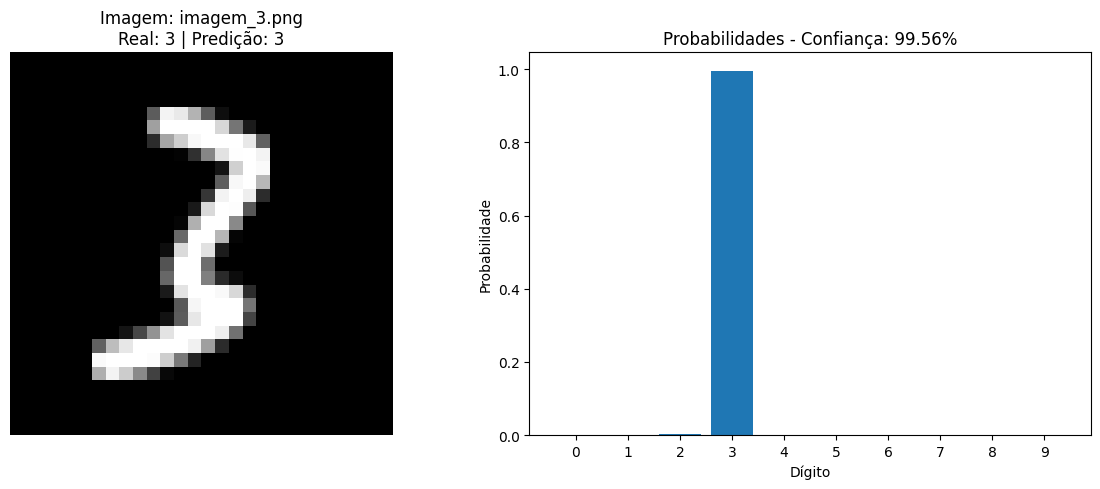

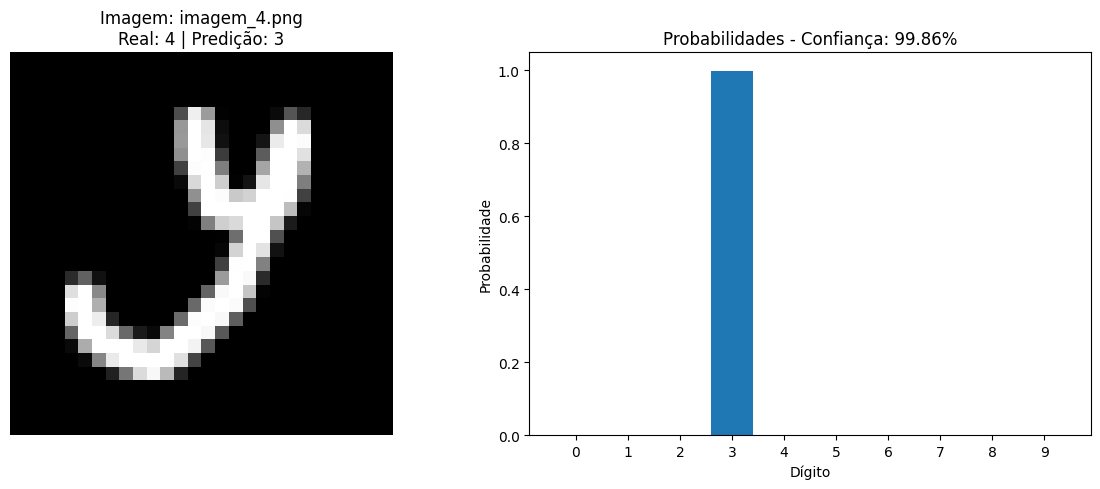

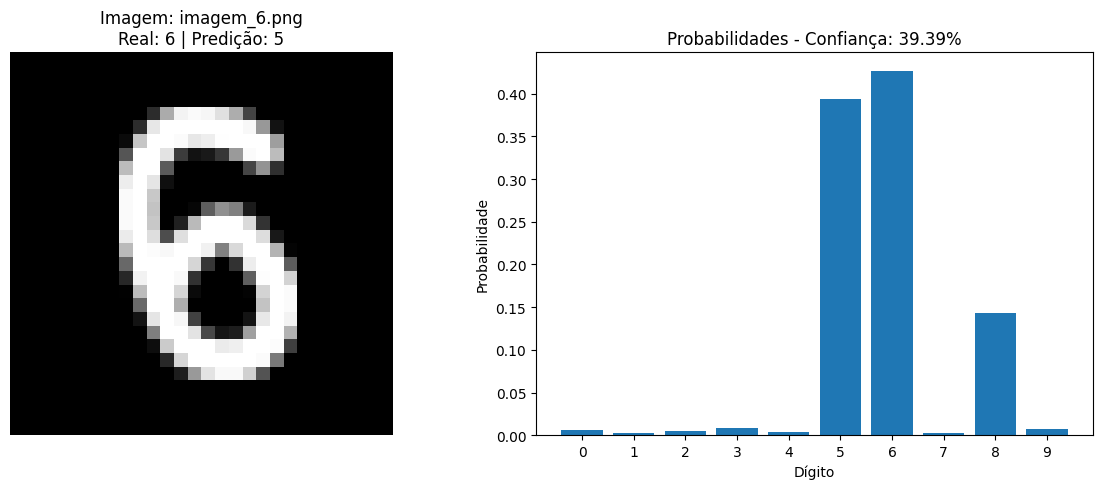

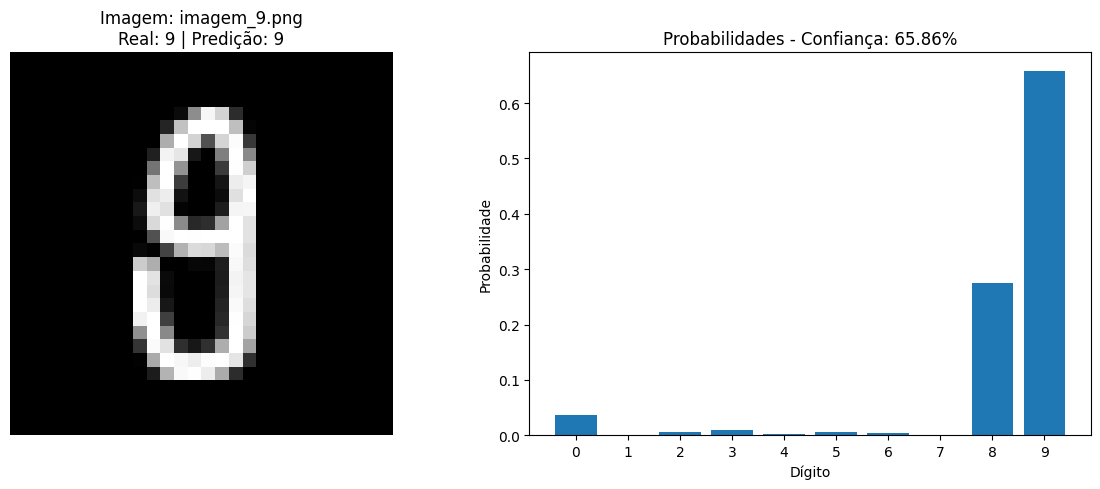

In [111]:
# ============================================================
# FASE 5.3 - TESTE COM IMAGENS MANUSCRITAS PRÓPRIAS
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re


# ------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ------------------------------------------------------------

pasta_imagens = Path("handwritten")

# Procura automaticamente todas as imagens PNG, JPG e JPEG
arquivos = []

for extensao in ["*.png", "*.jpg", "*.jpeg"]:
    arquivos.extend(pasta_imagens.glob(extensao))

arquivos = sorted(arquivos)

print(f"Imagens encontradas: {len(arquivos)}")

if len(arquivos) == 0:
    print("Nenhuma imagem encontrada.")
    print(f"Coloque suas imagens na pasta: {pasta_imagens}")


# ------------------------------------------------------------
# 2. FUNÇÃO DE PRÉ-PROCESSAMENTO
# ------------------------------------------------------------

def preprocessar_imagem(caminho):
    
    # Carregar imagem
    imagem = Image.open(caminho)
    
    # Converter para escala de cinza
    imagem_cinza = imagem.convert("L")
    
    # Inverter cores:
    # papel branco -> fundo preto
    # caneta preta -> dígito branco
    imagem_invertida = ImageOps.invert(imagem_cinza)
    
    # Converter para array
    array_imagem = np.array(imagem_invertida)
    
    # Encontrar pixels pertencentes ao dígito
    pixels = np.argwhere(array_imagem > 30)
    
    # Verificar se encontrou o dígito
    if len(pixels) == 0:
        raise ValueError("Nenhum dígito encontrado na imagem.")
    
    # Bounding Box
    y_min, x_min = pixels.min(axis=0)
    y_max, x_max = pixels.max(axis=0)
    
    imagem_recortada = imagem_invertida.crop(
        (x_min, y_min, x_max + 1, y_max + 1)
    )
    
    # --------------------------------------------------------
    # Redimensionamento mantendo proporção
    # --------------------------------------------------------
    
    largura, altura = imagem_recortada.size
    
    if largura > altura:
        nova_largura = 20
        nova_altura = int(altura * 20 / largura)
    else:
        nova_altura = 20
        nova_largura = int(largura * 20 / altura)
    
    imagem_redimensionada = imagem_recortada.resize(
        (nova_largura, nova_altura)
    )
    
    # --------------------------------------------------------
    # Criar imagem 28x28
    # --------------------------------------------------------
    
    imagem_28 = Image.new("L", (28, 28), 0)
    
    pos_x = (28 - nova_largura) // 2
    pos_y = (28 - nova_altura) // 2
    
    imagem_28.paste(
        imagem_redimensionada,
        (pos_x, pos_y)
    )
    
    # --------------------------------------------------------
    # Centralização pela massa
    # --------------------------------------------------------
    
    array_28 = np.array(imagem_28, dtype=float)
    
    y_indices, x_indices = np.indices(array_28.shape)
    
    massa_total = array_28.sum()
    
    centro_x = (x_indices * array_28).sum() / massa_total
    centro_y = (y_indices * array_28).sum() / massa_total
    
    deslocamento_x = int(round(13.5 - centro_x))
    deslocamento_y = int(round(13.5 - centro_y))
    
    imagem_centralizada = Image.new("L", (28, 28), 0)
    
    imagem_centralizada.paste(
        imagem_28,
        (deslocamento_x, deslocamento_y)
    )
    
    # --------------------------------------------------------
    # Normalização [0,1]
    # --------------------------------------------------------
    
    imagem_array = np.array(imagem_centralizada)
    
    imagem_normalizada = imagem_array / 255.0
    
    # --------------------------------------------------------
    # Transformar 28x28 em 1x784
    # --------------------------------------------------------
    
    imagem_modelo = imagem_normalizada.reshape(1, 784)
    
    return imagem_centralizada, imagem_modelo


# ------------------------------------------------------------
# 3. PROCESSAR E TESTAR TODAS AS IMAGENS
# ------------------------------------------------------------

resultados_imagens = []

for caminho in arquivos:
    
    try:
        
        # Pré-processamento
        imagem_processada, imagem_modelo = preprocessar_imagem(caminho)
        
        # Predição
        predicao = modelo_svm.predict(imagem_modelo)[0]
        
        # Probabilidades
        probabilidades = modelo_svm.predict_proba(imagem_modelo)[0]
        
        # ----------------------------------------------------
        # Tentar identificar o dígito real pelo nome
        # Exemplo: digito_2.png -> 2
        # ----------------------------------------------------
        
        correspondencia = re.search(r"(\d)", caminho.stem)
        
        if correspondencia:
            digito_real = int(correspondencia.group(1))
        else:
            digito_real = None
        
        # Confiança da previsão
        confianca = probabilidades[predicao]
        
        # Acerto
        if digito_real is not None:
            acertou = predicao == digito_real
        else:
            acertou = None
        
        # Guardar resultado
        resultados_imagens.append({
            "Imagem": caminho.name,
            "Digito_Real": digito_real,
            "Predicao": predicao,
            "Confianca": confianca,
            "Acertou": acertou
        })
        
        # ----------------------------------------------------
        # GRÁFICO
        # ----------------------------------------------------
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Imagem processada
        axes[0].imshow(
            imagem_processada,
            cmap="gray"
        )
        
        axes[0].axis("off")
        
        if digito_real is not None:
            titulo = (
                f"Imagem: {caminho.name}\n"
                f"Real: {digito_real} | "
                f"Predição: {predicao}"
            )
        else:
            titulo = (
                f"Imagem: {caminho.name}\n"
                f"Predição: {predicao}"
            )
        
        axes[0].set_title(titulo)
        
        # Gráfico das probabilidades
        axes[1].bar(
            range(10),
            probabilidades
        )
        
        axes[1].set_xticks(range(10))
        axes[1].set_xlabel("Dígito")
        axes[1].set_ylabel("Probabilidade")
        axes[1].set_title(
            f"Probabilidades - Confiança: "
            f"{confianca:.2%}"
        )
        
        plt.tight_layout()
        plt.show()
        
    except Exception as erro:
        
        print(f"Erro ao processar {caminho.name}: {erro}")


# ------------------------------------------------------------
# 4. TABELA CONSOLIDADA
# ------------------------------------------------------------

resultados_df = pd.DataFrame(resultados_imagens)

if len(resultados_df) > 0:
    
    resultados_df["Confianca"] = (
        resultados_df["Confianca"] * 100
    ).round(2)
    
    resultados_df